In [1]:
import pandas as pd 
df = pd.read_csv("gemini_25_flash.csv")
df

,Unnamed: 0,unique_problem_label,ten_percentile_group,method,total_tokens,correct,params,result_description
0,0,MathArena/cmimc_2025: 16,5,reflexion,49787.0,False,max_attempt=3,NaN
1,0,MathArena/cmimc_2025: 16,5,tot,1612774.0,False,all=4,NaN
2,0,MathArena/cmimc_2025: 16,5,rejection_sampling_basic,597448.0,False,n_steps=20,NaN
3,0,MathArena/cmimc_2025: 16,5,rejection_sampling_summarized,538780.0,False,n_steps=10,2nd
4,0,MathArena/aime_2025: 20,4,reflexion,66965.0,True,max_attempt=3,NaN
5,0,MathArena/aime_2025: 20,4,tot,213862.0,True,all=3,NaN
6,0,MathArena/aime_2025: 20,4,rejection_sampling_basic,200213.0,True,n_steps=10,NaN
7,0,MathArena/aime_2025: 20,4,rejection_sampling_summarized,367313.0,True,n_steps=5,NaN
8,0,MathArena/hmmt_feb_2025: 18,3,reflexion,31132.0,True,max_attempt=3,NaN
9,0,MathArena/hmmt_feb_2025: 18,3,tot,456549.0,False,all=3,NaN


In [2]:
def rename_n_steps(df: pd.DataFrame):

  # Assuming your DataFrame is named 'df'
  valA = 'rejection_sampling_basic'  # Replace with your actual value for ColoumA
  old_string = 'n_steps'
  new_string = 'n_swaps'

  # 1. Create a boolean mask to select the desired rows
  mask = df['method'] == valA

  # 2. Use .loc to select the rows/column and perform the string replacement
  df.loc[mask, 'params'] = (
      df.loc[mask, 'params']
      .str.replace(old_string, new_string, regex=False)
  )
  return df 

rename_n_steps(df)

,Unnamed: 0,unique_problem_label,ten_percentile_group,method,total_tokens,correct,params,result_description
0,0,MathArena/cmimc_2025: 16,5,reflexion,49787.0,False,max_attempt=3,NaN
1,0,MathArena/cmimc_2025: 16,5,tot,1612774.0,False,all=4,NaN
2,0,MathArena/cmimc_2025: 16,5,rejection_sampling_basic,597448.0,False,n_swaps=20,NaN
3,0,MathArena/cmimc_2025: 16,5,rejection_sampling_summarized,538780.0,False,n_steps=10,2nd
4,0,MathArena/aime_2025: 20,4,reflexion,66965.0,True,max_attempt=3,NaN
5,0,MathArena/aime_2025: 20,4,tot,213862.0,True,all=3,NaN
6,0,MathArena/aime_2025: 20,4,rejection_sampling_basic,200213.0,True,n_swaps=10,NaN
7,0,MathArena/aime_2025: 20,4,rejection_sampling_summarized,367313.0,True,n_steps=5,NaN
8,0,MathArena/hmmt_feb_2025: 18,3,reflexion,31132.0,True,max_attempt=3,NaN
9,0,MathArena/hmmt_feb_2025: 18,3,tot,456549.0,False,all=3,NaN


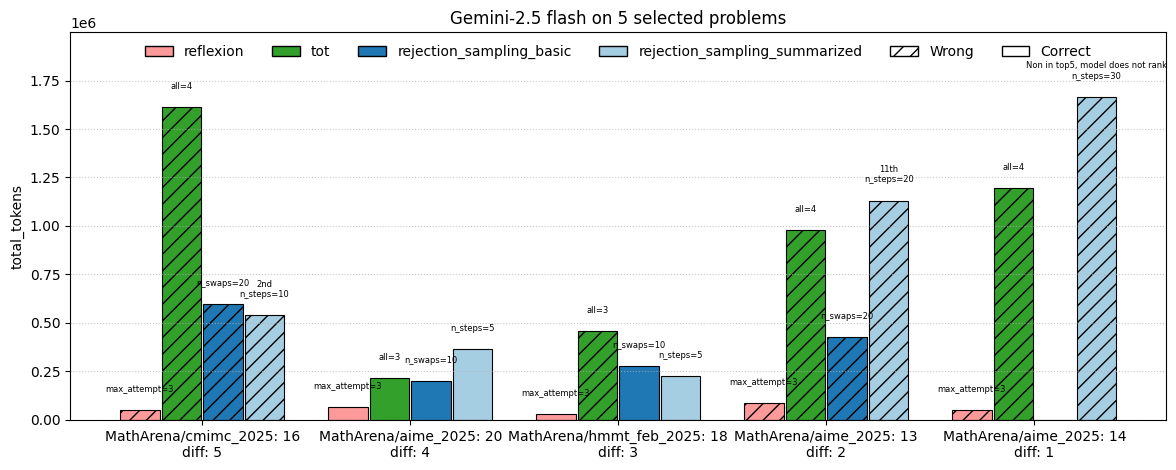

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch



def rename_n_steps(df: pd.DataFrame):

  valA = 'rejection_sampling_basic'  
  old_string = 'n_steps'
  new_string = 'n_swaps'

  # 1. Create a boolean mask to select the desired rows
  mask = df['method'] == valA

  # 2. Use .loc to select the rows/column and perform the string replacement
  df.loc[mask, 'params'] = (
      df.loc[mask, 'params']
      .str.replace(old_string, new_string, regex=False)
  )
  return df 


def plot_session(
    df: pd.DataFrame,
    title: str,
    levels: bool = True,
    height_col: str | None = None,          # e.g. "score" or "total_tokens"
    correct_col: str = "correct",
    fill_missing_height: float = 0.0,
):
    df = rename_n_steps(df)
    text_col: str = "result_description"
    correct_col: str = "correct"
    param_col = "params"
    # stable order
    problems = df["unique_problem_label"].drop_duplicates().tolist()
    methods  = df["method"].drop_duplicates().tolist()

    # choose default height col
    if height_col is None:
        height_col = "score" if "score" in df.columns else "total_tokens"

    # pivot to (problem x method)
    H  = (df.pivot(index="unique_problem_label", columns="method", values=height_col)
            .reindex(index=problems, columns=methods)
            .fillna(fill_missing_height)
            .to_numpy(dtype=float))

    OK = (df.pivot(index="unique_problem_label", columns="method", values=correct_col)
            .reindex(index=problems, columns=methods))

    result_destr = (df.pivot(index="unique_problem_label", columns="method", values=text_col)
             .reindex(index=problems, columns=methods))
    param_destr = (df.pivot(index="unique_problem_label", columns="method", values=param_col)
             .reindex(index=problems, columns=methods))
             

    # x tick labels
    groups = problems
    if levels:
        groups = [
            f"{p}\ndiff: {df.loc[df['unique_problem_label']==p, 'ten_percentile_group'].iloc[0]}"
            for p in problems
        ]

    colors = ["#fb9a99", "#33a02c", "#1f78b4", "#a6cee3"]
    colors = (colors * ((len(methods) + len(colors) - 1)//len(colors)))[:len(methods)]

    n_groups, n_bars = len(problems), len(methods)
    x = np.arange(n_groups)
    group_width = 0.8
    bar_w = group_width / n_bars
    offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * bar_w 

    fig, ax = plt.subplots(figsize=(12, 4.8))

    ymax = float(np.nanmax(H))
    ymin = 0.0
    if ymax == 0:
        ymax = 1.0
    ypad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)

    for j, method in enumerate(methods):
        xpos = x + offsets[j]
        bars = ax.bar(
            xpos,
            H[:, j],
            width=bar_w * 0.95,
            color=colors[j],
            edgecolor="black",
            linewidth=0.8,
            label=method,
        )

        for i, b in enumerate(bars):
            ok_val = OK.iloc[i, j]
            has_row = pd.notna(ok_val) or (H[i, j] != fill_missing_height)  # heuristic

            # hatch only if we actually have an observation and it's wrong
            if has_row and (pd.notna(ok_val) and (not bool(ok_val))):
                b.set_hatch("//")

            res = result_destr.iloc[i, j] if pd.notna(result_destr.iloc[i, j]) else ""
            par = param_destr.iloc[i, j] if pd.notna(param_destr.iloc[i, j]) else ""
            txt = res + "\n" + par
            if pd.isna(txt) or str(txt).strip() == "":
                continue

            h = b.get_height()
            y = min(h + ypad, ymax + 2*ypad)
            ax.text(
                b.get_x() + b.get_width() / 2,
                y,
                str(txt),
                ha="center",
                va="bottom",
                fontsize=6,
                clip_on=True,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylabel(height_col)
    ax.set_title(title)
    ax.set_ylim(ymin, ymax + 4*ypad)
    ax.grid(axis="y", linestyle=":", alpha=0.7)

    legend_handles = (
        [Patch(facecolor=colors[i], edgecolor="black", label=methods[i]) for i in range(len(methods))]
        + [Patch(facecolor="white", edgecolor="black", hatch="//", label="Wrong"),
           Patch(facecolor="white", edgecolor="black", label="Correct")]
    )
    ax.legend(handles=legend_handles, ncol=min(6, len(legend_handles)), frameon=False, loc="upper center")

    plt.tight_layout()
    plt.show()

plot_session(df, "Gemini-2.5 flash on 5 selected problems", height_col="total_tokens")



In [4]:
import pandas as pd 
df = pd.read_csv("gpt-5-nano.csv")
df

,Unnamed: 0,unique_problem_label,ten_percentile_group,method,total_tokens,correct,params,result_description
0,0,MathArena/brumo_2025: 21,8,reflexion,51640,True,max_attempt=3,NaN
1,0,MathArena/brumo_2025: 21,8,tot,193183,True,all=4,NaN
2,0,MathArena/brumo_2025: 21,8,rejection_sampling_basic,75289,False,n_steps=10,NaN
3,0,MathArena/brumo_2025: 21,8,rejection_sampling_summarized,206756,False,n_steps=10,2nd
4,0,MathArena/brumo_2025: 25,6,reflexion,26699,True,max_attempt=3,NaN
5,0,MathArena/brumo_2025: 25,6,tot,137327,True,all=3,NaN
6,0,MathArena/brumo_2025: 25,6,rejection_sampling_basic,64185,True,n_steps=10,NaN
7,0,MathArena/brumo_2025: 25,6,rejection_sampling_summarized,201577,True,n_steps=10,NaN
8,0,MathArena/cmimc_2025: 5,4,reflexion,6139,False,max_attempt=3,NaN
9,0,MathArena/cmimc_2025: 5,4,tot,92400,False,all=3,NaN


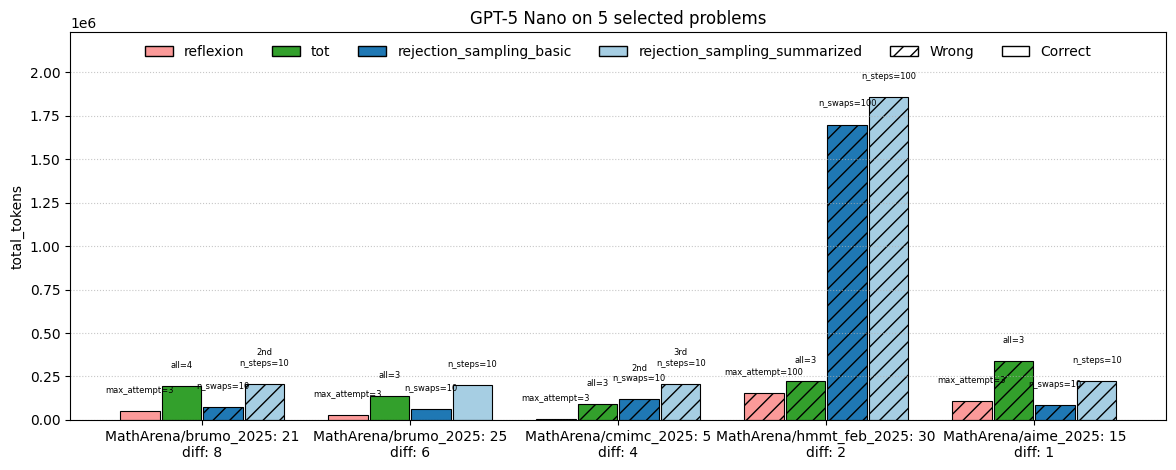

In [5]:
plot_session(df, "GPT-5 Nano on 5 selected problems", height_col="total_tokens")
